# Predicting trip durations

A simple machine learning workflow featuring various regression models.

## Data loading and logging config

A bit of a overengineering here but setting up logging for *best practices* and bit of a self-recap.

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

In [4]:
import pickle
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

Load the datasets into the session.

In [5]:
train_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet"
valid_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet"

try:
    current_path = train_data_path
    train_data = pd.read_parquet(train_data_path)
    logging.info(f"Dataset {train_data_path} sucessfully loaded.")
    
    current_path = valid_data_path
    valid_data = pd.read_parquet(valid_data_path)
    logging.info(f"Dataset {valid_data_path} sucessfully loaded.")
    
except HTTPError as e:
    logging.error(f"HTTP Error {e.code}: The file was not found at {current_path}.")
    
except URLError as e:
    logging.critical(f"Network Connection Error at {current_path}: Could not resolve the server. Reason: {e.reason}")
    
except Exception as e:
    logging.error(f"An unexpected error occurred while reading {current_path}: {e}")

2026-09-13 19:44:10 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet sucessfully loaded.
2026-09-13 19:44:11 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet sucessfully loaded.


## Notes (in chronological order)

### Create the target variable

First, we feature engineer the target variable `trip_duration` from the dropoff (`lpep_dropoff_datetime`) and pickup (`lpep_pickup_datetime`) datime variables. The durations are converted to minutes with `td.total_seconds()`. Durations are filtered to a range of 1-60 minutes.

In [12]:
train_data["trip_duration"] = train_data["lpep_dropoff_datetime"] - train_data["lpep_pickup_datetime"]
train_data.trip_duration = train_data.trip_duration.dt.total_seconds().div(60).round(3)

In [13]:
# train_data.trip_duration.quantile([.25, .5, .75, .9, .95, .99])

In [14]:
df = train_data[(train_data.trip_duration >= 1) & (train_data.trip_duration <= 60)]

### Feature engineering

Additional features were generated from `lpep_pickup_datetime`:
* `pickup_hour`
* `day_of_week`
* `day_of_month`

A `trip_id` feature was created as a combination feature of `PULocationID` and `DOLocationID`.

In [17]:
# numerical = ['trip_distance']  is a posteriori feature and will contribute to data leakage
df["pickup_hour"] = df.lpep_pickup_datetime.dt.hour
df["day_of_week"] = df.lpep_pickup_datetime.dt.day_of_week
df["day_of_month"] = df.lpep_pickup_datetime.dt.month

df["trip_id"] = df.PULocationID.astype(str) + "_" + df.DOLocationID.astype(str)

### Feature selection

Here, both numerical and categorical features are selected.

Note: In the zoomcamp, `trip_distance` was selected as a numerical feature. I chose to exclude the `trip_distance` since I view it to be an a posteriori feature, something collected *after* an observation. If the distance is not an estimated value, then this may contribute to **data leakage**, where the model "sees" some data that it would not have in a practical scenario.

In [82]:
num_features = ["pickup_hour", "day_of_week", "day_of_month"]
cat_features = ["trip_id"]

### One-hot encoding categories

In this notebook, since we are dealing already with a `DataFrame`, I chose to use the standard `ColumnTransformer`, from `sklearn.compose`. These provide better handling of schema and data drift errors, and are also used in production systems, due to their flexibility to mixed data types with more control. 

I'll be doing some studying on their differences in the [comparing-sklearn-transformers](comparing-sklearn-transformers.ipynb) notebook.

In [23]:
transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat_features),
        ('num', "passthrough", num_features)
    ]
)

In [24]:
X_train = transformer.fit_transform(df)

In [12]:
target = "trip_duration"
y_train = df[target].values

### Fit regression models

Linear, lasso, and ridge regression models are fit to the training data. Prediction distributions are plotted against the validation data. The RMSE and relative RMSE scores are computed as well for each model.

The regularization penalty (alpha) was set to 0.0001 for both lasso and ridge regression models. Based on the metrics, all models performed similarly, hovering around an RMSE of 6.8 minutes.

In [98]:
def read_dataframe(filename: str) -> pd.DataFrame:
    try:
        if not (filename.endswith(".csv") or filename.endswith(".parquet")):
            e = f"Unsupported file format for {filename}. Must be .csv or .parquet."
            logging.error(e)
            raise ValueError(e)
        
        if filename.endswith(".csv"):
            df = pd.read_csv(filename)

            # datetime features in csv files are not automatically parsed
            df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
            df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
        
        elif filename.endswith(".parquet"):
            df = pd.read_parquet(filename)
        
        logging.info(f"Dataset {filename} sucessfully loaded.")
        
        df["trip_duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
        df.trip_duration = df.trip_duration.apply(lambda td: td.total_seconds() / 60)
        logging.info(f"Duration feature succesfully created.")
        
        df = df[(df.trip_duration >= 1) & (df.trip_duration <= 60)]

        df["pickup_hour"] = df.lpep_pickup_datetime.dt.hour
        df["day_of_week"] = df.lpep_pickup_datetime.dt.dayofweek
        df["day_of_month"] = df.lpep_pickup_datetime.dt.day
        df["trip_id"] = df.PULocationID.astype(str) + "_" + df.DOLocationID.astype(str)
        
        return df
        
    except HTTPError as e:
        logging.error(f"HTTP Error {e.code}: The file was not found at {filename}.")
        raise
        
    except URLError as e:
        logging.critical(f"Network Connection Error at {filename}: Could not resolve the server. Reason: {e.reason}")
        raise
        
    except Exception as e:
        logging.error(f"An unexpected error occurred while reading {filename}: {e}")
        raise


def process(
    train_data: pd.DataFrame, 
    valid_data: pd.DataFrame, 
    cat_features: list[str], 
    num_features: list[str],
    target: str = "trip_duration"
) -> tuple[object, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    
    transformer = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown="ignore"), cat_features),
            ('num', "passthrough", num_features)
        ]
    )
    logging.info("ColumnTransformer initialised with OneHotEncoder.")
    
    X_train_raw = train_data[cat_features + num_features]
    X_valid_raw = valid_data[cat_features + num_features]
    
    y_train = train_data[target].values
    y_valid = valid_data[target].values

    X_train = transformer.fit_transform(X_train_raw)
    logging.info("Transformer successfully fit and transformed training data.")
    X_valid = transformer.transform(X_valid_raw)
    logging.info("Validation data successfully transformed.")

    return transformer, X_train, y_train, X_valid, y_valid


def plot_dist(title, pred, actual):
    sns.histplot(pred, label="prediction", bins=50, kde=True, edgecolor=None)
    sns.histplot(actual, label="actual", bins=50, kde=True, edgecolor=None)
    plt.title(title)
    plt.legend()
    plt.show()

In [99]:
train_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet"
valid_data_path = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet"

train_data = read_dataframe(train_data_path)
valid_data = read_dataframe(valid_data_path)

2026-09-13 23:37:29 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet sucessfully loaded.
2026-09-13 23:37:29 [INFO] Duration feature succesfully created.
2026-09-13 23:37:30 [INFO] Dataset https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet sucessfully loaded.
2026-09-13 23:37:30 [INFO] Duration feature succesfully created.


In [100]:
num_features = ["pickup_hour", "day_of_week", "day_of_month"]
cat_features = ["trip_id"]

transformer, X_train, y_train, X_valid, y_valid = process(
    train_data=train_data, 
    valid_data=valid_data, 
    cat_features=cat_features, 
    num_features=num_features,
)

2026-09-13 23:37:30 [INFO] ColumnTransformer initialised with OneHotEncoder.
2026-09-13 23:37:30 [INFO] Transformer successfully fit and transformed training data.
2026-09-13 23:37:30 [INFO] Validation data successfully transformed.


In [101]:
def run_model(model, X, y):
    logging.info(f"Starting: model <{model}> run")
    model.fit(X, y)
    logging.info(f"Model successfully fit to the data.")
    pred = model.predict(X_valid)
    logging.info(f"Model predictions generated.")
    rmse = root_mean_squared_error(y_valid, pred)
    rrmse = round(rmse / y_valid.mean(), 4)
    logging.info(f"Prediction metrics generated.")
    return pred, rmse, rrmse

In [107]:
linreg = LinearRegression()
lasso = Lasso(alpha=0.0001)
ridge = Ridge(alpha=0.0001)
summary = {}

for model in (linreg, lasso, ridge):
    pred, rmse, rrmse = run_model(model, X_train, y_train)
    summary[model] = {"pred": pred, "rmse": round(rmse, 4), "rrmse": float(rrmse)*100}

2026-09-13 23:38:16 [INFO] Starting: model <LinearRegression()> run
2026-09-13 23:38:16 [INFO] Model successfully fit to the data.
2026-09-13 23:38:16 [INFO] Model predictions generated.
2026-09-13 23:38:16 [INFO] Prediction metrics generated.
2026-09-13 23:38:16 [INFO] Starting: model <Lasso(alpha=0.0001)> run
2026-09-13 23:38:19 [INFO] Model successfully fit to the data.
2026-09-13 23:38:19 [INFO] Model predictions generated.
2026-09-13 23:38:19 [INFO] Prediction metrics generated.
2026-09-13 23:38:19 [INFO] Starting: model <Ridge(alpha=0.0001)> run
2026-09-13 23:38:19 [INFO] Model successfully fit to the data.
2026-09-13 23:38:19 [INFO] Model predictions generated.
2026-09-13 23:38:19 [INFO] Prediction metrics generated.


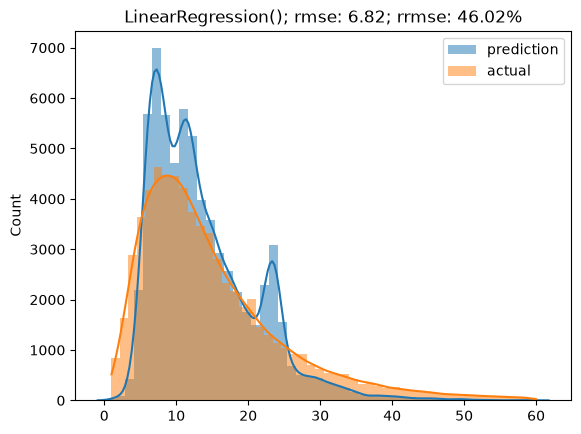

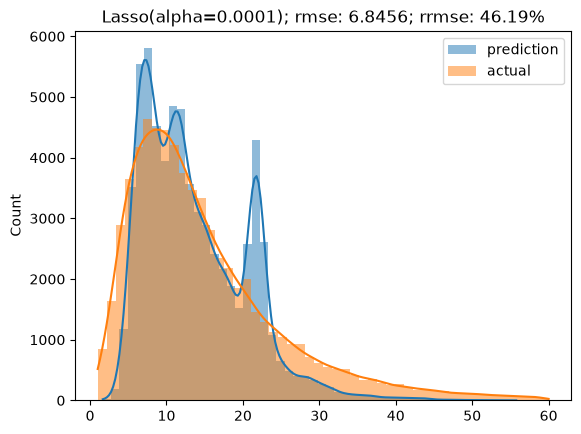

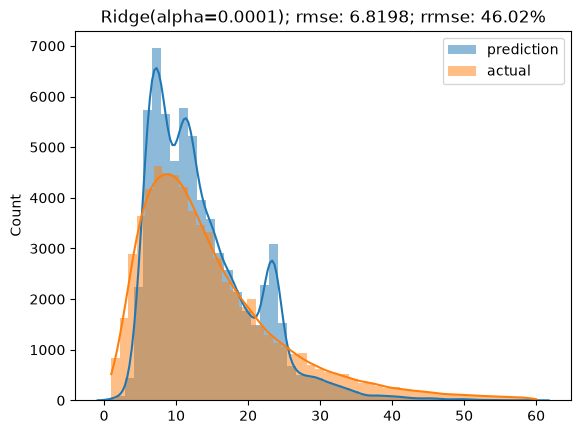

In [108]:
for model in summary:
    plot_dist(
        f"{model}; rmse: {summary[model]["rmse"]}; rrmse: {summary[model]["rrmse"]}%", 
        summary[model]["pred"], 
        y_valid
    )

In [109]:
with open("models/ridge.bin", "wb") as f_out:
    pickle.dump((transformer, ridge), f_out)

## Conclusion

This was a good refresher on building a simple machine learning workflow. Couple of foundational concepts were covered in the notebook:

* Basic logging and exception handling
* Feature engineering
* Training and validation sets
* One-hot encoding (with `sklearn` transformers)
* Basic distribution plotting
* Model training and evaluation metrics

Overall, the workflow is successful. 

However, 6.8 minutes may be a little high, especially for trip durations that are lesser than 10 minutes long. We can implement some hyperparameter tuning to improve the models, moving forward. That brings us to the next steps, which will be to implement experiment tracking with `MLFlow` so that we are able to automatically record hyperparameters, versions, metrics, and artifacts over many model runs.